Successfully imported necessary libraries for descriptive analysis

In [262]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels as sm
import scipy as sc
import seaborn as sns

Import dataframes for descriptive analysis

In [263]:
life_expectancy = pd.read_csv('../Datasets/Cleaned_datasets/Life_expectancy_cleaned_1.csv').drop(columns=['Unnamed: 0'])

highest_grossing = pd.read_csv('../Datasets/Cleaned_datasets/Top_Grossing_Countries-per_capita.csv').drop(columns=['Unnamed: 0'])
lowest_grossing = pd.read_csv('../Datasets/Cleaned_datasets/Lowest_Grossing_Countries-per_capita.csv').drop(columns=['Unnamed: 0'])

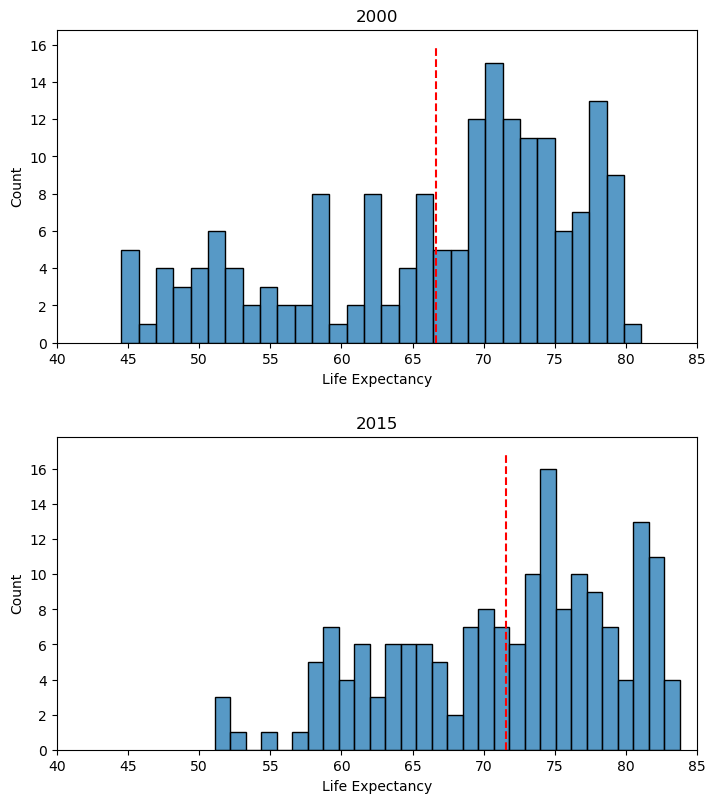

<Figure size 500x400 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [264]:
year_2000_le_all = life_expectancy['life_expectancy'][life_expectancy['year'] == 2000]
year_2000_le_mean = np.mean(life_expectancy['life_expectancy'][life_expectancy['year'] == 2000])
year_2015_le_all = life_expectancy['life_expectancy'][life_expectancy['year'] == 2015]
year_2015_le_mean = np.mean(life_expectancy['life_expectancy'][life_expectancy['year'] == 2015])


plt.subplot(2, 1, 1)
sns.histplot(list(year_2000_le_all), bins=30)
plt.subplots_adjust(0, 1, 1, 2.5, 3, 0.3)
plt.vlines(year_2000_le_mean, 0, 16, colors='red', linestyles='--')
plt.title('2000')
plt.xlabel('Life Expectancy')
plt.xlim(40, 85)
plt.subplot(2, 1, 2)
sns.histplot(list(year_2015_le_all), bins=30)
plt.vlines(year_2015_le_mean, 0, 17, colors='red', linestyles='--')
plt.title('2015')
plt.xlabel('Life Expectancy')
plt.xlim(40, 85)
plt.figure(figsize= [5, 4])
plt.show()
plt.clf()

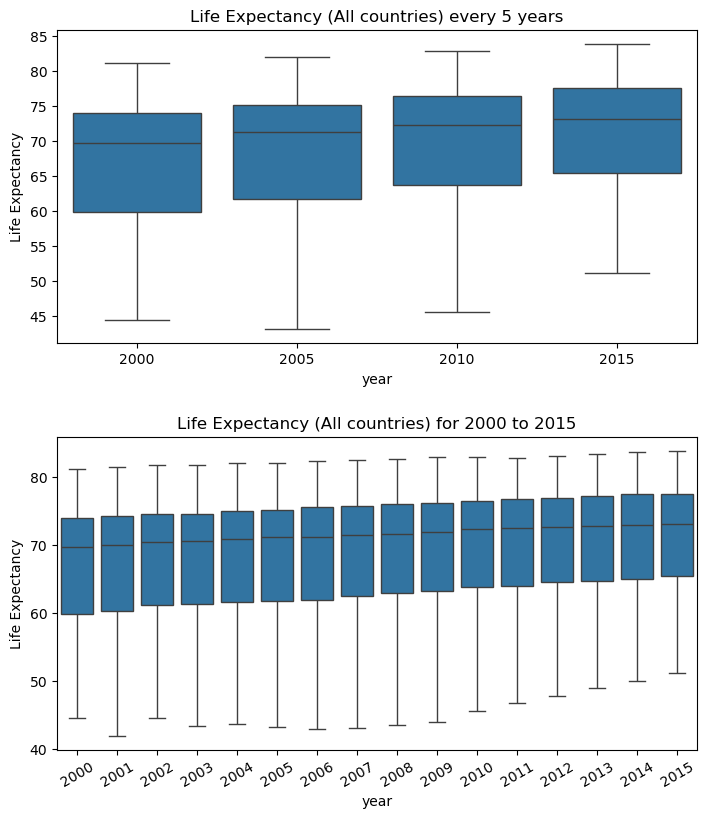

<Figure size 640x480 with 0 Axes>

In [265]:
le_all_2000_and_2015 = life_expectancy[(life_expectancy['year'] == 2000) | (life_expectancy['year'] == 2015) | (life_expectancy['year'] == 2005) | (life_expectancy['year'] == 2010)]
le_all_2000_to_2015 = life_expectancy

ax1 = plt.subplot(2, 1, 1)
sns.boxplot(x = le_all_2000_and_2015['year'], y = le_all_2000_and_2015['life_expectancy'])
plt.title('Life Expectancy (All countries) every 5 years')
plt.ylabel('Life Expectancy')
plt.subplots_adjust(0, 1, 1, 2.5, 3, 0.3)
ax2 = plt.subplot(2, 1, 2)
sns.boxplot(x = le_all_2000_to_2015['year'], y = le_all_2000_to_2015['life_expectancy'])
plt.title('Life Expectancy (All countries) for 2000 to 2015')
plt.ylabel('Life Expectancy')
plt.xticks(rotation = 30)
plt.show()
plt.clf()

Create dataframe containing life expectancy mean, maximum, minimum and median values of all countries by year

In [266]:
years_list_mean = []
means_list = []
for year in range(2000, 2016):
    mean = np.mean(life_expectancy['life_expectancy'].where(life_expectancy.year == year))
    years_list_mean.append(year)
    means_list.append(np.round(mean, 2))
all_means_dict = {'year': years_list_mean, 'mean': means_list}

all_means_df = pd.DataFrame(all_means_dict)


In [267]:
years_list_max = []
max_list = []
for year in range(2000, 2016):
    max = np.max(life_expectancy['life_expectancy'].where(life_expectancy.year == year))
    years_list_max.append(year)
    max_list.append(max)
all_max_dict = {'year': years_list_max, 'max': max_list}

all_max_df = pd.DataFrame(all_max_dict)

In [268]:
years_list_min = []
min_list = []
for year in range(2000, 2016):
    min = np.min(life_expectancy['life_expectancy'].where(life_expectancy.year == year))
    years_list_min.append(year)
    min_list.append(min)
all_min_dict = {'year': years_list_min, 'minimum': min_list}

all_min_df = pd.DataFrame(all_min_dict)

In [269]:
years_list_median = []
median_list = []
for year in range(2000, 2016):
    median = np.median((life_expectancy['life_expectancy'].where(life_expectancy.year == year)).dropna().reset_index(drop=True))
    years_list_median.append(year)
    median_list.append(round(median, 2))
all_median_dict = {'year': years_list_median, 'median': median_list}

all_median_df = pd.DataFrame(all_median_dict)

In [270]:
descriptive_stats_life_exp =all_means_df.merge(all_max_df, on='year').merge(all_min_df, on='year').merge(all_median_df, on='year')

Create dataframe with mean, min, max and median life expectancy aggregates for:
1.  Top 20 grossing countries per capita
2.  Bottom 20 grossing countries per capita

In [271]:
# 20 Highest grossing countries
years_list_mean = []
means_list_top_gdp = []
for year in range(2000, 2016):
    mean = np.mean(highest_grossing['life_expectancy'].where(highest_grossing.year == year))
    years_list_mean.append(year)
    means_list_top_gdp.append(np.round(mean, 2))
all_means_dict_top = {'year': years_list_mean, 'mean': means_list_top_gdp}

all_means_top_gdp_df = pd.DataFrame(all_means_dict_top)

# 20 Lowest grossing countries
means_list_bottom_gdp = []
for year in range(2000, 2016):
    mean = np.mean(lowest_grossing['life_expectancy'].where(lowest_grossing.year == year))
    means_list_bottom_gdp.append(np.round(mean, 2))
all_means_dict_bottom = {'year': years_list_mean, 'mean': means_list_bottom_gdp}

all_means_bottom_gdp_df = pd.DataFrame(all_means_dict_bottom)

In [272]:
# 20 Highest grossing countries
years_list_max = []
max_list_top_gdp = []
for year in range(2000, 2016):
    max = np.max(highest_grossing['life_expectancy'].where(highest_grossing.year == year))
    years_list_max.append(year)
    max_list_top_gdp.append(max)
all_max_dict_top = {'year': years_list_max, 'max': max_list_top_gdp}

all_max_top_gdp_df = pd.DataFrame(all_max_dict_top)

# 20 Lowest grossing countries
max_list_bottom_gdp = []
for year in range(2000, 2016):
    max = np.max(lowest_grossing['life_expectancy'].where(lowest_grossing.year == year))
    max_list_bottom_gdp.append(max)
all_max_dict_bottom = {'year': years_list_max, 'max': max_list_bottom_gdp}

all_max_bottom_gdp_df = pd.DataFrame(all_max_dict_bottom)

In [273]:
# 20 Highest grossing countries
years_list_min = []
min_list_top_gdp = []
for year in range(2000, 2016):
    min = np.min(highest_grossing['life_expectancy'].where(highest_grossing.year == year))
    years_list_min.append(year)
    min_list_top_gdp.append(min)
all_min_top_gdp_dict = {'year': years_list_min, 'minimum': min_list_top_gdp}

all_min_top_gdp_df = pd.DataFrame(all_min_top_gdp_dict)

# 20 Lowest grossing countries
min_list_bottom_gdp = []
for year in range(2000, 2016):
    min = np.min(lowest_grossing['life_expectancy'].where(lowest_grossing.year == year))
    min_list_bottom_gdp.append(min)
all_min_bottom_gdp_dict = {'year': years_list_min, 'minimum': min_list_bottom_gdp}

all_min_bottom_gdp_df = pd.DataFrame(all_min_bottom_gdp_dict)

In [274]:
# 20 Highest grossing countries
years_list_median = []
median_list_top_gdp = []
for year in range(2000, 2016):
    median = np.median((highest_grossing['life_expectancy'].where(highest_grossing.year == year)).dropna().reset_index(drop=True))
    years_list_median.append(year)
    median_list_top_gdp.append(round(median, 2))
all_median_top_gdp_dict = {'year': years_list_median, 'median': median_list_top_gdp}

all_median_top_gdp_df = pd.DataFrame(all_median_top_gdp_dict)

# 20 Lowest grossing countries
median_list_bottom_gdp = []
for year in range(2000, 2016):
    median = np.median((lowest_grossing['life_expectancy'].where(lowest_grossing.year == year)).dropna().reset_index(drop=True))
    median_list_bottom_gdp.append(round(median, 2))
all_median_bottom_gdp_dict = {'year': years_list_median, 'median': median_list_bottom_gdp}

all_median_bottom_gdp_df = pd.DataFrame(all_median_bottom_gdp_dict)

In [275]:
# 20 Highest grossing countries
descriptive_stats_life_exp_top_gdp =all_means_top_gdp_df.merge(all_max_top_gdp_df, on='year').merge(all_min_top_gdp_df, on='year').merge(all_median_top_gdp_df, on='year')

# 20 Lowest grossing countries
descriptive_stats_life_exp_bottom_gdp =all_means_bottom_gdp_df.merge(all_max_bottom_gdp_df, on='year').merge(all_min_bottom_gdp_df, on='year').merge(all_median_bottom_gdp_df, on='year')

Create boxplots for 20 Lowest grosing countries over the last 20 years

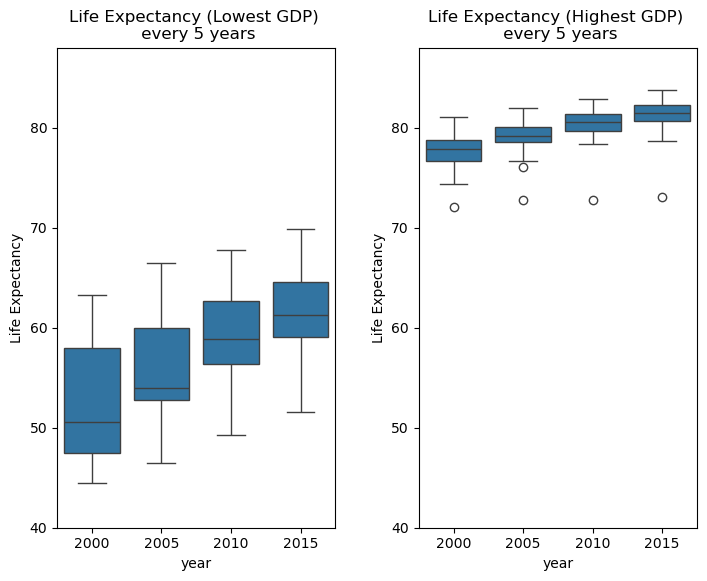

<Figure size 640x480 with 0 Axes>

In [ ]:
le_bottom_2000_and_2015 = lowest_grossing[(lowest_grossing['year'] == 2000) | (lowest_grossing['year'] == 2015) | (lowest_grossing['year'] == 2005) | (lowest_grossing['year'] == 2010)]
le_bottom_2000_to_2015 = lowest_grossing

le_top_2000_and_2015 = highest_grossing[(highest_grossing['year'] == 2000) | (highest_grossing['year'] == 2015) | (highest_grossing['year'] == 2005) | (highest_grossing['year'] == 2010)]
le_top_2000_to_2015 = highest_grossing

ax1 = plt.subplot(1, 2, 1)
sns.boxplot(x = le_bottom_2000_and_2015['year'], y = le_bottom_2000_and_2015['life_expectancy'])
plt.title('Life Expectancy (Lowest GDP) \n every 5 years')
plt.ylabel('Life Expectancy')
plt.subplots_adjust(0, 1, 1, 2, 0.3, 0)
plt.ylim(40, 88)
ax3 = plt.subplot(1, 2, 2)
sns.boxplot(x = le_top_2000_and_2015['year'], y = le_top_2000_and_2015['life_expectancy'])
plt.title('Life Expectancy (Highest GDP) \n every 5 years')
plt.ylabel('Life Expectancy')
plt.ylim(40, 88)
plt.show()
plt.clf()


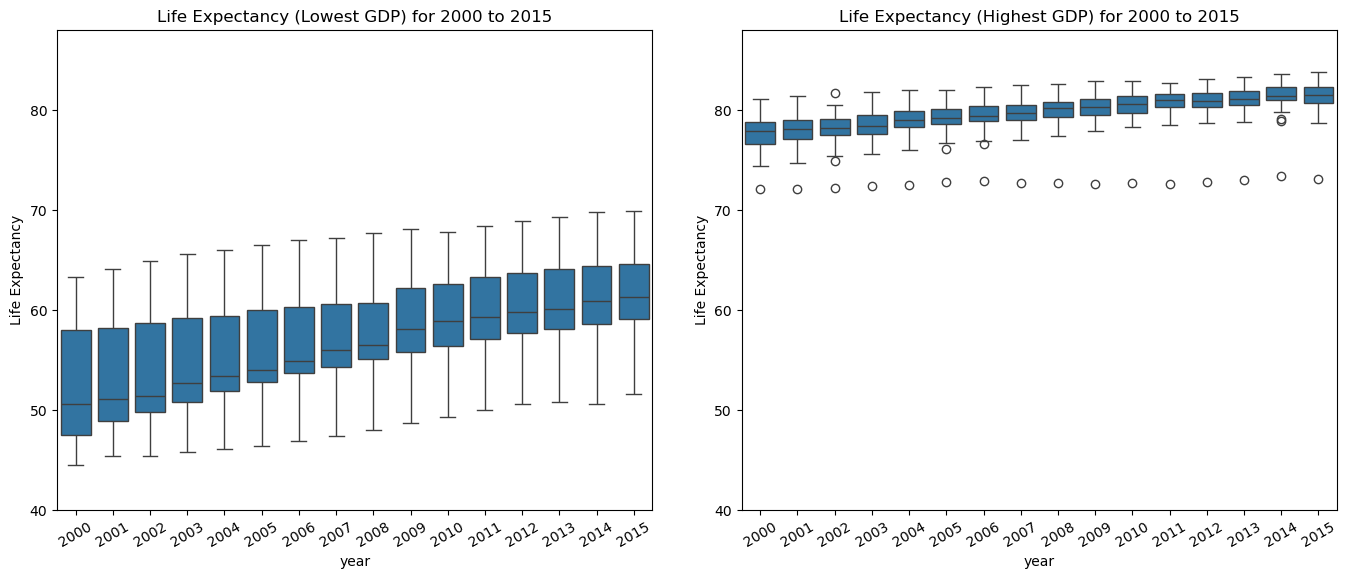

<Figure size 640x480 with 0 Axes>

In [277]:

ax2 = plt.subplot(1, 2, 1)
sns.boxplot(x = le_bottom_2000_to_2015['year'], y = le_bottom_2000_to_2015['life_expectancy'])
plt.title('Life Expectancy (Lowest GDP) for 2000 to 2015')
plt.ylabel('Life Expectancy')
plt.xticks(rotation = 30)
plt.ylim(40, 88)
plt.subplots_adjust(0, 1, 2, 2, 0.15, 0)
ax4 = plt.subplot(1, 2, 2)
sns.boxplot(x = le_top_2000_to_2015['year'], y = le_top_2000_to_2015['life_expectancy'])
plt.title('Life Expectancy (Highest GDP) for 2000 to 2015')
plt.ylabel('Life Expectancy')
plt.xticks(rotation = 30)
plt.ylim(40, 88)
plt.show()
plt.clf()

Calculate number of unique countries for both lowest and highest grossing countries from 2000 to 2015, to observe how many countries circulated in the lowest gdp per capita area.

In [278]:
unique_highest_gdp_counries = []

for year in range(2000, 2016):
    le_highest_20_gdp = life_expectancy[life_expectancy['year'] == year].sort_values(by='gdp_per_capita', ascending=False).reset_index(drop=True)
    le_highest_20_gdp = le_highest_20_gdp.iloc[:20]
    for country in list(le_highest_20_gdp['country']):
        if country not in unique_highest_gdp_counries:
            unique_highest_gdp_counries.append(country)
        else:
            continue
print(f'There are {len(np.unique(unique_highest_gdp_counries))} unique countries in the 20 highest grossing counries per capita from 2000 to 2015')

unique_lowest_gdp_counries = []

for year in range(2000, 2016):
    le_lowest_20_gdp = life_expectancy[life_expectancy['year'] == year].sort_values(by='gdp_per_capita', ascending=True).reset_index(drop=True)
    le_lowest_20_gdp = le_lowest_20_gdp.iloc[:20]
    for country in list(le_lowest_20_gdp['country']):
        if country not in unique_lowest_gdp_counries:
            unique_lowest_gdp_counries.append(country)
        else:
            continue
print(f'There are {len(np.unique(unique_lowest_gdp_counries))} unique countries in the 20 lowest grossing counries per capita from 2000 to 2015')

There are 26 unique countries in the 20 highest grossing counries per capita from 2000 to 2015
There are 30 unique countries in the 20 lowest grossing counries per capita from 2000 to 2015
